In [1]:

# Install required packages
!pip -q install yfinance tensorflow scikit-learn pandas matplotlib


In [2]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


TensorFlow version: 2.20.0
NumPy version: 2.1.3


## 1. Load Apple (AAPL) stock data

In [3]:

# Choose data source:
# "yahoo" = automatically download AAPL data
# "upload" = upload your own CSV file

DATA_SOURCE = "yahoo"

# Date range for the project
START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

if DATA_SOURCE.lower() == "yahoo":
    df = yf.download(
        "AAPL",
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False
    )

    # Flatten MultiIndex columns if returned by yfinance
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()

else:
    from google.colab import files

    uploaded = files.upload()
    filename = next(iter(uploaded))
    df = pd.read_csv(filename)

print("Shape:", df.shape)
display(df.head())


Shape: (2766, 7)


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,24.171753,27.332500,27.860001,26.837500,27.847500,212818400
1,2015-01-05,23.490795,26.562500,27.162500,26.352501,27.072500,257142000
2,2015-01-06,23.493013,26.565001,26.857500,26.157499,26.635000,263188400
3,2015-01-07,23.822441,26.937500,27.049999,26.674999,26.799999,160423600
4,2015-01-08,24.737745,27.972500,28.037500,27.174999,27.307501,237458000


In [4]:

# Standardize column names and identify required columns
df.columns = [str(c).strip() for c in df.columns]

# Find Date and Close columns case-insensitively
date_col = next((c for c in df.columns if c.lower() == "date"), None)
close_col = next((c for c in df.columns if c.lower() == "close"), None)

if date_col is None or close_col is None:
    raise ValueError(
        f"Dataset must contain Date and Close columns. Found: {list(df.columns)}"
    )

# Keep useful columns if available
keep_cols = [date_col, close_col]
for c in ["Open", "High", "Low", "Adj Close", "Volume"]:
    if c in df.columns and c not in keep_cols:
        keep_cols.append(c)

df = df[keep_cols].copy()
df = df.rename(columns={date_col: "Date", close_col: "Close"})

# Convert types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

# Clean
df = (
    df.dropna(subset=["Date", "Close"])
      .drop_duplicates(subset=["Date"])
      .sort_values("Date")
      .reset_index(drop=True)
)

print("Cleaned shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Missing values:")
print(df.isna().sum())

display(df.head())
display(df.tail())


Cleaned shape: (2766, 7)
Date range: 2015-01-02 to 2025-12-31
Missing values:
Date         0
Close        0
Open         0
High         0
Low          0
Adj Close    0
Volume       0
dtype: int64


,Date,Close,Open,High,Low,Adj Close,Volume
0,2015-01-02,27.332500,27.847500,27.860001,26.837500,24.171753,212818400
1,2015-01-05,26.562500,27.072500,27.162500,26.352501,23.490795,257142000
2,2015-01-06,26.565001,26.635000,26.857500,26.157499,23.493013,263188400
3,2015-01-07,26.937500,26.799999,27.049999,26.674999,23.822441,160423600
4,2015-01-08,27.972500,27.307501,28.037500,27.174999,24.737745,237458000


,Date,Close,Open,High,Low,Adj Close,Volume
2761,2025-12-24,273.809998,272.339996,275.429993,272.200012,273.066711,17910600
2762,2025-12-26,273.399994,274.160004,275.369995,272.859985,272.657867,21521800
2763,2025-12-29,273.760010,272.690002,274.359985,272.350006,273.016876,23715200
2764,2025-12-30,273.079987,272.809998,274.079987,272.279999,272.338684,22139600
2765,2025-12-31,271.859985,273.059998,273.679993,271.750000,271.122009,27293600


## 2. Exploratory visualization

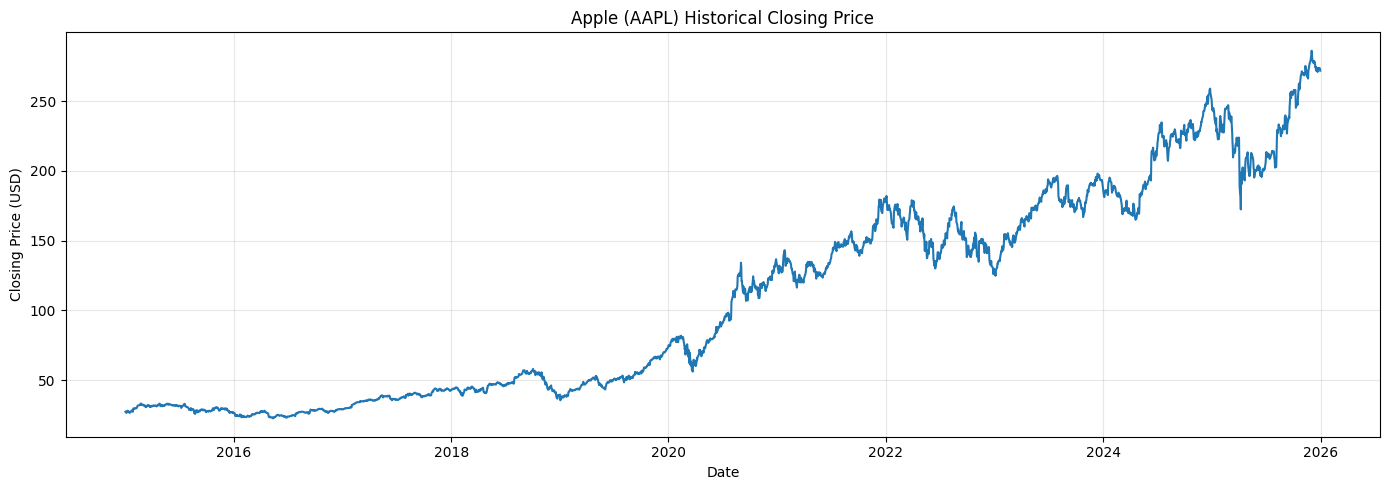

In [5]:

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Apple (AAPL) Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:

# Basic statistics
display(df["Close"].describe().to_frame("Close Price"))

# Recent prices
display(df.tail(10)[["Date", "Close"]])


,Close Price
count,2766.000000
mean,108.644931
std,73.856228
min,22.584999
25%,39.080626
50%,91.204998
75%,170.830006
max,286.190002


,Date,Close
2756,2025-12-17,271.839996
2757,2025-12-18,272.190002
2758,2025-12-19,273.670013
2759,2025-12-22,270.970001
2760,2025-12-23,272.359985
2761,2025-12-24,273.809998
2762,2025-12-26,273.399994
2763,2025-12-29,273.760010
2764,2025-12-30,273.079987
2765,2025-12-31,271.859985



## 3. Chronological train/test split

Because this is time-series data, we **do not randomly shuffle** the observations.

We use:

- **80%** of the earliest observations for training
- **20%** of the latest observations for testing

This mimics a real forecasting situation: learn from the past and predict the future.


In [7]:

TRAIN_RATIO = 0.80

close_values = df[["Close"]].values.astype("float32")
split_idx = int(len(close_values) * TRAIN_RATIO)

train_raw = close_values[:split_idx]
test_raw = close_values[split_idx:]

train_dates = df["Date"].iloc[:split_idx].reset_index(drop=True)
test_dates = df["Date"].iloc[split_idx:].reset_index(drop=True)

print("Training observations:", len(train_raw))
print("Testing observations :", len(test_raw))
print("Training period:", train_dates.iloc[0].date(), "to", train_dates.iloc[-1].date())
print("Testing period :", test_dates.iloc[0].date(), "to", test_dates.iloc[-1].date())


Training observations: 2212
Testing observations : 554
Training period: 2015-01-02 to 2023-10-16
Testing period : 2023-10-17 to 2025-12-31



## 4. Normalize the data

We use **Min-Max Scaling** so that the model receives values in approximately the range 0–1.

The scaler is fitted **only on the training data** to avoid leaking future test information into training.


In [8]:

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_raw)

# Transform test data using the training-fitted scaler
test_scaled = scaler.transform(test_raw)

print("Original training range:", train_raw.min(), "to", train_raw.max())
print("Scaled training range  :", train_scaled.min(), "to", train_scaled.max())


Original training range: 22.585 to 196.45
Scaled training range  : 0.0 to 1.0000001



## 5. Create 60-day sliding-window sequences

Each input sequence contains the previous **60 trading days**.

Example:

`Days 1–60 → Day 61`

`Days 2–61 → Day 62`

`Days 3–62 → Day 63`

This converts the stock-price series into supervised learning examples.


In [9]:

LOOKBACK = 60

def create_sequences(data, lookback):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, 0])
        y.append(data[i, 0])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X.reshape(-1, lookback, 1), y

X_train, y_train = create_sequences(train_scaled, LOOKBACK)

# For the test set, prepend the final 60 training values.
# This allows the first test prediction to use the immediately preceding history.
test_input = np.concatenate([train_scaled[-LOOKBACK:], test_scaled], axis=0)
X_test, y_test = create_sequences(test_input, LOOKBACK)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


X_train shape: (2152, 60, 1)
y_train shape: (2152,)
X_test shape : (554, 60, 1)
y_test shape : (554,)



## 6. Build the LSTM model

Architecture:

**Input → LSTM(64) → Dropout → LSTM(32) → Dense(16) → Dense(1)**

The final Dense layer contains one neuron because the target is one continuous value: the next closing price.


In [10]:

tf.keras.backend.clear_session()

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.20),

    LSTM(32),
    Dropout(0.20),

    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model

In [11]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.10,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - loss: 0.0036 - mae: 0.0444 - val_loss: 0.0025 - val_mae: 0.0411
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0102 - mae: 0.0844 - val_loss: 0.0555 - val_mae: 0.2133
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0209 - mae: 0.1111 - val_loss: 0.0063 - val_mae: 0.0684
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0245 - mae: 0.1250 - val_loss: 0.0278 - val_mae: 0.1528
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0130 - mae: 0.0949 - val_loss: 0.0085 - val_mae: 0.0789
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0078 - mae: 0.0703 - val_loss: 0.0091 - val_mae: 0.0814
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0057 - mae: 0.0536 - val_loss: 0.0055 - val_mae: 0.0586
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0036 - mae: 0.0392 - val_loss: 0.0048 - val_mae: 0.0593
Epoch 9/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.00

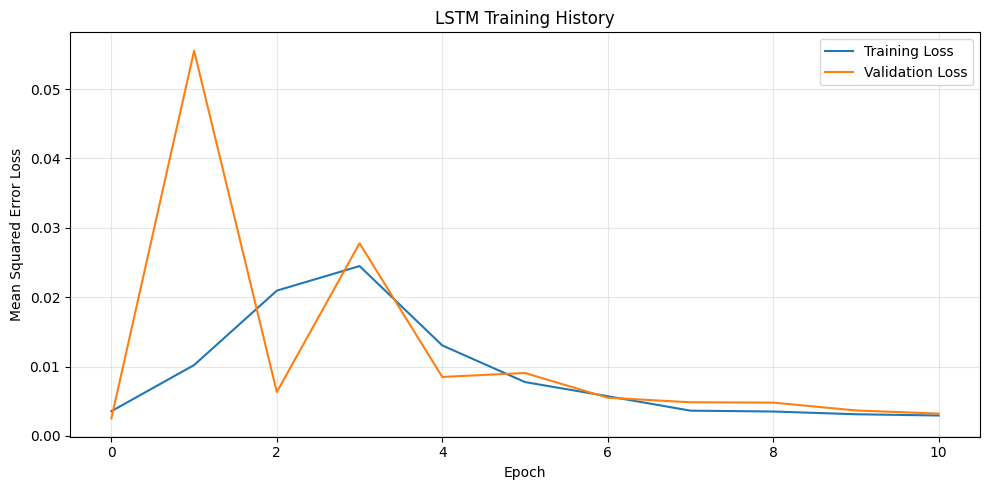

In [12]:

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Predict the test period

In [13]:

pred_scaled = model.predict(X_test, verbose=0)

# Convert predictions and actual values back to USD
predicted_prices = scaler.inverse_transform(pred_scaled).flatten()
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Dates corresponding to the test predictions
prediction_dates = df["Date"].iloc[split_idx:].reset_index(drop=True)

print("Predictions:", len(predicted_prices))
print("Actual values:", len(actual_prices))
print("Dates:", len(prediction_dates))


Predictions: 554
Actual values: 554
Dates: 554


## 9. Model evaluation

In [14]:

mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

# MAPE can be unstable when actual values are zero.
non_zero = actual_prices != 0
mape = np.mean(
    np.abs(
        (actual_prices[non_zero] - predicted_prices[non_zero])
        / actual_prices[non_zero]
    )
) * 100

print(f"MAE  : ${mae:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


MAE  : $24.46
RMSE : $28.38
MAPE : 10.64%


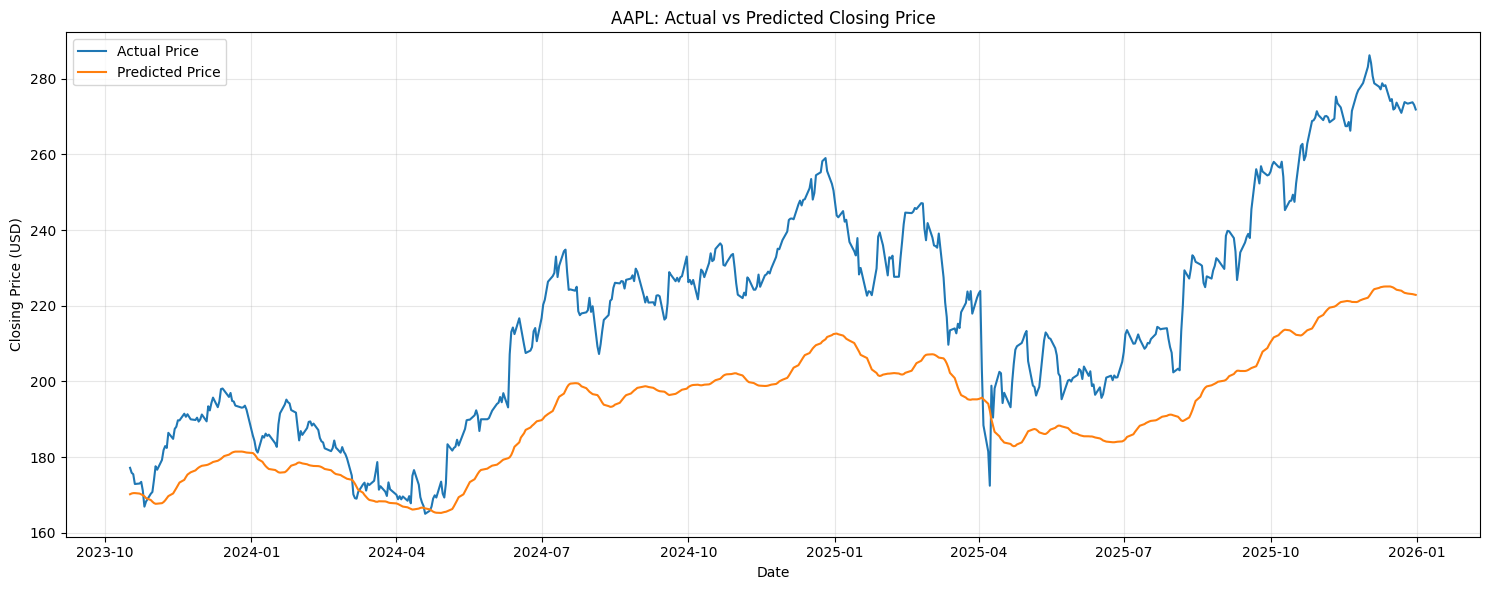

In [15]:

# Actual vs Predicted
plt.figure(figsize=(15, 6))
plt.plot(prediction_dates, actual_prices, label="Actual Price")
plt.plot(prediction_dates, predicted_prices, label="Predicted Price")
plt.title("AAPL: Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


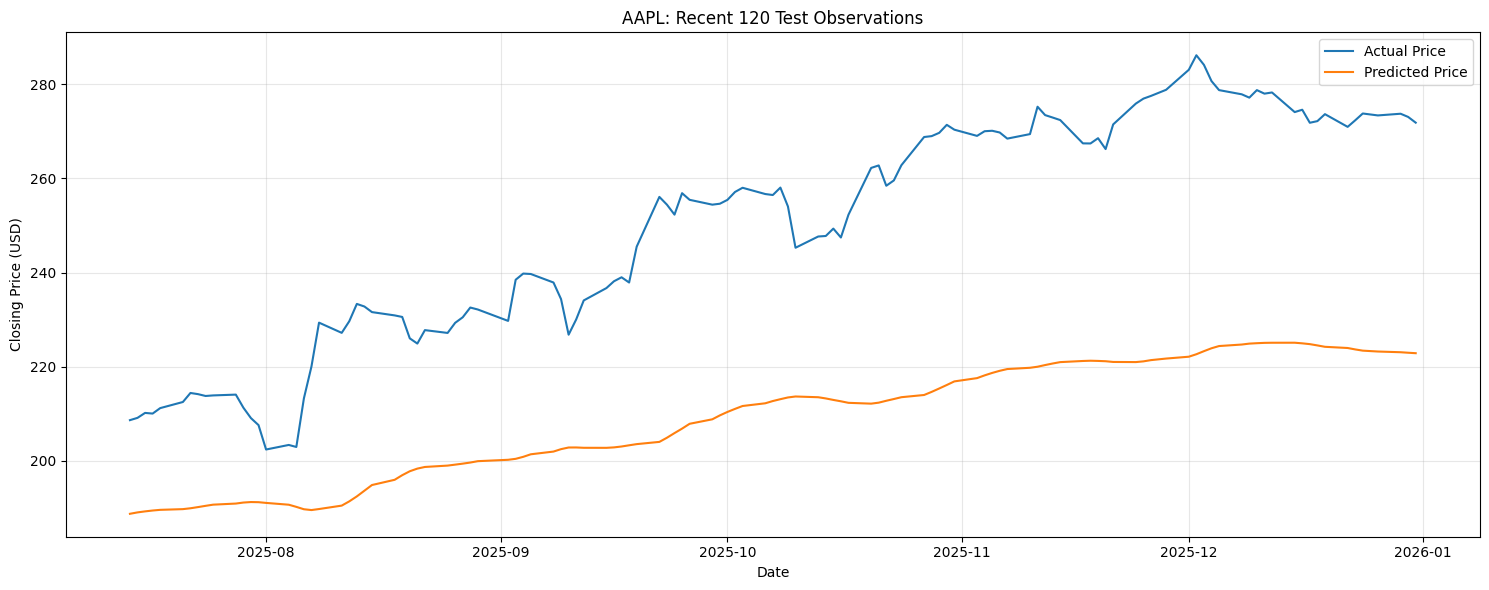

In [16]:

# Zoom into the most recent 120 test observations
n_zoom = min(120, len(actual_prices))

plt.figure(figsize=(15, 6))
plt.plot(
    prediction_dates.iloc[-n_zoom:],
    actual_prices[-n_zoom:],
    label="Actual Price"
)
plt.plot(
    prediction_dates.iloc[-n_zoom:],
    predicted_prices[-n_zoom:],
    label="Predicted Price"
)
plt.title(f"AAPL: Recent {n_zoom} Test Observations")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Sample predictions

In [17]:

results = pd.DataFrame({
    "Date": prediction_dates,
    "Actual_Close": actual_prices,
    "Predicted_Close": predicted_prices
})

results["Absolute_Error"] = np.abs(
    results["Actual_Close"] - results["Predicted_Close"]
)

display(results.tail(15))


,Date,Actual_Close,Predicted_Close,Absolute_Error
539,2025-12-10,278.779999,224.980530,53.799469
540,2025-12-11,278.029999,225.051605,52.978394
541,2025-12-12,278.279999,225.075745,53.204254
542,2025-12-15,274.109985,225.081696,49.028290
543,2025-12-16,274.609985,224.950684,49.659302
544,2025-12-17,271.839996,224.780518,47.059479
545,2025-12-18,272.190002,224.508224,47.681778
546,2025-12-19,273.670013,224.213074,49.456940
547,2025-12-22,270.970001,223.960068,47.009933
548,2025-12-23,272.359985,223.657471,48.702515



## 11. Forecast the next trading day

The final 60 observed closing prices are passed to the trained LSTM.

The output is the model's estimate of the **next unseen trading day's closing price**.

Note: this is a model forecast for an academic assignment, **not financial advice** and not a guarantee of future market performance.


In [18]:

# Last 60 observed scaled prices
last_60 = scaler.transform(df[["Close"]].tail(LOOKBACK).values)

X_next = last_60.reshape(1, LOOKBACK, 1)

next_scaled = model.predict(X_next, verbose=0)
next_price = scaler.inverse_transform(next_scaled)[0, 0]

last_date = df["Date"].iloc[-1]

# Approximate next business day (actual market holidays are not considered here)
next_business_day = last_date + pd.tseries.offsets.BDay(1)

print(f"Last observed date : {last_date.date()}")
print(f"Last actual close   : ${df['Close'].iloc[-1]:.2f}")
print(f"Forecast date       : {next_business_day.date()}")
print(f"Forecasted close    : ${next_price:.2f}")


Last observed date : 2025-12-31
Last actual close   : $271.86
Forecast date       : 2026-01-01
Forecasted close    : $222.74
